In [3]:
import pandas as pd
import numpy as np
from IPython.display import display_html

In [9]:
# loading and reading dataset
df = pd.read_csv("C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Lab\\Lab 3\\Data_Quality.csv")
print(df.head())
df.head(2)

   Unnamed: 0 Category Rank Unique_Identifier Seller_State Seller_City  \
0           0    Phone   14          X12JI92X    Karnataka   Bangalore   
1           1      Tab   53          ABXI98IB       Kerala      Kannur   
2           2    Phone   55          PPQ129IN    Karnataka      Magadi   
3           3    Phone  3.9          KLIO9900    Karnataka   Mangalore   
4           4    Phone   57          SBX9INJ2       Kerala  Trivandrum   

   Postal_Code  
0       560004  
1       670001  
2       560023  
3       575003  
4       695002  


,Unnamed: 0,Category,Rank,Unique_Identifier,Seller_State,Seller_City,Postal_Code
0,0,Phone,14,X12JI92X,Karnataka,Bangalore,560004
1,1,Tab,53,ABXI98IB,Kerala,Kannur,670001


In [10]:
display_html(f"<h3><br/>Accuray Checks for Cateogory", raw=True)
Expected_Category = 'Phone' + '|' + 'Tab' + '|' + 'Laptop'
print("Expected_Category are : ", Expected_Category)
if(sum(~df['Category'].str.contains(Expected_Category, na =False))==0):
 display_html(f"<h3><br/> - No category apart from Phone, Tab or Laptop", raw=True)
else:
 display_html(f"<h3><br/> Below records does belong to expected category", raw=True)
 display(df[~df['Category'].str.contains(Expected_Category, na =False)][['Category']])

Accuray Checks for Cateogory

Expected_Category are :  Phone|Tab|Laptop


- No category apart from Phone, Tab or Laptop

In [11]:
display_html(f"<h3><br/>Accuracy Checks for Rank", raw=True)
# Check 1
if(sum(df['Rank'].apply(str).str.isdigit() == False)==0):
 display_html(f"<h3><br/>Check 1 : Rank have only Integer Values", raw=True)
else:
 display_html(f"<h3><br/>Check 1 : Ranks which does not have Integer Values", raw=True)
 display(df[df['Rank'].apply(str).str.isdigit() == False][['Category','Rank']])

# Check 2 --
temp_df = df[df['Rank'].apply(str).str.isdigit() == True]
if(temp_df.shape[0]==df.shape[0]):
 display_html(f"<h3><br/>Check 2 : Rank with Integer Values falls under boundary values", raw=True)
else:
 display_html(f"<h3><br/>Check 2 : Ranks with Integer Values does not falls under boundary values ", raw=True)
 display(temp_df[~temp_df['Rank'].astype(int).between(1, 50)][['Category','Rank']])

Accuracy Checks for Rank

Check 1 : Ranks which does not have Integer Values

,Category,Rank
3,Phone,3.9
7,Phone,VC


Check 2 : Ranks with Integer Values does not falls under boundary values

,Category,Rank
1,Tab,53
2,Phone,55
4,Phone,57
8,Phone,51


In [12]:
display_html(f"<h3><br/>Accuracy Checks for Unique_Identifier", raw=True)
# Check 1
if(sum(df['Unique_Identifier'].str.isalnum() == False)==0):
 display_html(f"<h3><br/>Check 1 : Unique_Identifier is alphanumeric", raw=True)
else:
 display_html(f"<h3><br/>Check 1 : Unique_Identifier is not alphanumeric", raw=True)
 display(df[df['Unique_Identifier'].str.isalnum() == False][['Category','Unique_Identifier']])

# Check 2
temp_df = df[df['Unique_Identifier'].str.isalnum() == True]
if(sum(temp_df['Unique_Identifier'].str.len() != 8)==0):
 display_html(f"<h3><br/>Check 2 : Unique_Identifier which are alphanumeric have only 8 characters", raw=True)
else:
 display_html(f"<h3><br/>Check 2 : Unique_Identifier which are alphanumeric with character length not equal to 8", raw=True)
 display(temp_df[temp_df['Unique_Identifier'].str.len()!= 8][['Category','Unique_Identifier']])

Accuracy Checks for Unique_Identifier

Check 1 : Unique_Identifier is not alphanumeric

,Category,Unique_Identifier
7,Phone,ABC$5678


Check 2 : Unique_Identifier which are alphanumeric with character length not equal to 8

,Category,Unique_Identifier
9,Phone,BBXR66G


In [13]:
display_html(f"<h3><br/>Accuracy Checks for Seller_State", raw=True)
print("Expected_Category are : ", 'Karnataka or Kerala')
if(sum(~df['Seller_State'].str.contains('Karnataka|Kerala', na =False))==0):
 display_html(f"<h3><br/> - Seller belongs to Karnataka or Kerala ", raw=True)
else:
 display_html(f"<h3><br/> - Seller apart from Karnataka or Kerala", raw=True)
 display(df[~df['Seller_State'].str.contains('Karnataka|Kerala', na =False)][['Seller_State','Category']])

Accuracy Checks for Seller_State

Expected_Category are :  Karnataka or Kerala


- Seller belongs to Karnataka or Kerala

In [16]:
city_info = pd.read_csv("C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Lab\\Lab 3\\State-city-pincode.csv")
display_html(f"<h3><br/>Accuracy Check for Seller_State - Seller City", raw=True)
State_list = ['Karnataka','Kerala']
postal_start= [5,6] # For Postal Code Checks
counter = 0
postal = df.copy()
for i in range(len(State_list)):
 df_cities = df[df['Seller_State']==State_list[i]]['Seller_City'].unique()
 correct_cities = city_info[city_info['State']==State_list[i]]['Cities'].unique()
 wrng_city = [i for i in df_cities if i not in correct_cities]
 if(len(wrng_city)!=0):
  counter +=1
  display_html(f"<h3><br/> - Check failed for {State_list[i]}", raw=True)
  print(f'\nWrong Mapping in cities list for {State_list[i]} is/are : {wrng_city}')
  display(df[(df['Seller_City'].isin(wrng_city)) & (df['Seller_State']==State_list[i])][['Seller_State','Seller_City']])
  postal = postal.drop(df[(df['Seller_City'].isin(wrng_city)) & (df['Seller_State']==State_list[i])].index)## Creating DataFrame for Postal Code Checks
if counter==0:
 display_html(f"<h3><br/> All cities are mapped properly", raw=True)

Accuracy Check for Seller_State - Seller City

- Check failed for Karnataka


Wrong Mapping in cities list for Karnataka is/are : ['Trivandrum', 'Kannur']


,Seller_State,Seller_City
5,Karnataka,Trivandrum
8,Karnataka,Kannur


- Check failed for Kerala


Wrong Mapping in cities list for Kerala is/are : ['Bangalore']


,Seller_State,Seller_City
6,Kerala,Bangalore


In [17]:
# Display header for accuracy check
display_html(f"<h3><br/>Accuracy Check for Postal Code</h3>", raw=True)
# Check 1: Verify all postal codes have 6 digits
if len(postal[postal['Postal_Code'].apply(str).str.len() != 6].index) != 0:
 display_html(f"<h3><br/>Check 1 - - Postal Code with less than 6 digits</h3>", raw=True)
 display(postal[postal['Postal_Code'].apply(str).str.len() != 6])
 postal.drop(postal[postal['Postal_Code'].apply(str).str.len() != 6].index, inplace=True)
else:
 display_html(f"<h3><br/>Check 1 - All Postal Codes are 6 digits</h3>", raw=True)
    
# Check 2: Verify each postal code matches the correct starting digits for its state
temp_df_list = [] # Create a list to store mismatched dataframes
for i in range(len(State_list)):
 mismatches = postal[(postal['Seller_State'] == State_list[i]) & (~postal['Postal_Code'].apply(str).str.startswith(str(postal_start[i])))]
 temp_df_list.append(mismatches)
temp_df = pd.concat(temp_df_list, ignore_index=True) # Concatenate all mismatched dataframes
if temp_df.shape[0] == 0:
 display_html(f"<h3><br/>Check 2 - All 6-digit Postal Codes are properly mapped</h3>", raw=True)
else:
 display_html(f"<h3><br/>Check 2 - Postal Codes with 6 digits mapped incorrectly</h3>", raw=True)
 display(temp_df[['Seller_State', 'Postal_Code']])


Accuracy Check for Postal Code

Check 1 - - Postal Code with less than 6 digits

,Unnamed: 0,Category,Rank,Unique_Identifier,Seller_State,Seller_City,Postal_Code
9,9,Phone,7,BBXR66G,Karnataka,Bangalore,67890


Check 2 - All 6-digit Postal Codes are properly mapped

In [19]:
l1 = df['Category'].unique().tolist()
l1.sort()
l2 = Expected_Category.split('|')
if(l1==l2):
 display(f"<h3><br/> Data Set have all 3 categories", raw=True)
else:
 display_html(f"<h3><br/> Data Set does not have all 3 categories", raw=True)
 display_html(f"<h3><br/>Expected categories are {Expected_Category.split('|')}, but we have only categories {df['Category'].unique().tolist()}", raw=True)

Data Set does not have all 3 categories

Expected categories are ['Phone', 'Tab', 'Laptop'], but we have only categories ['Phone', 'Tab']

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib as mpl
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # statistical data visualization

In [4]:
df = pd.read_csv(r"C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Lab\\Lab 3\\AirPassengers.csv")
df.head()
#We should rename the columns:
df.columns = ['Date','Number of Passengers']
df.head()

,Date,Number of Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


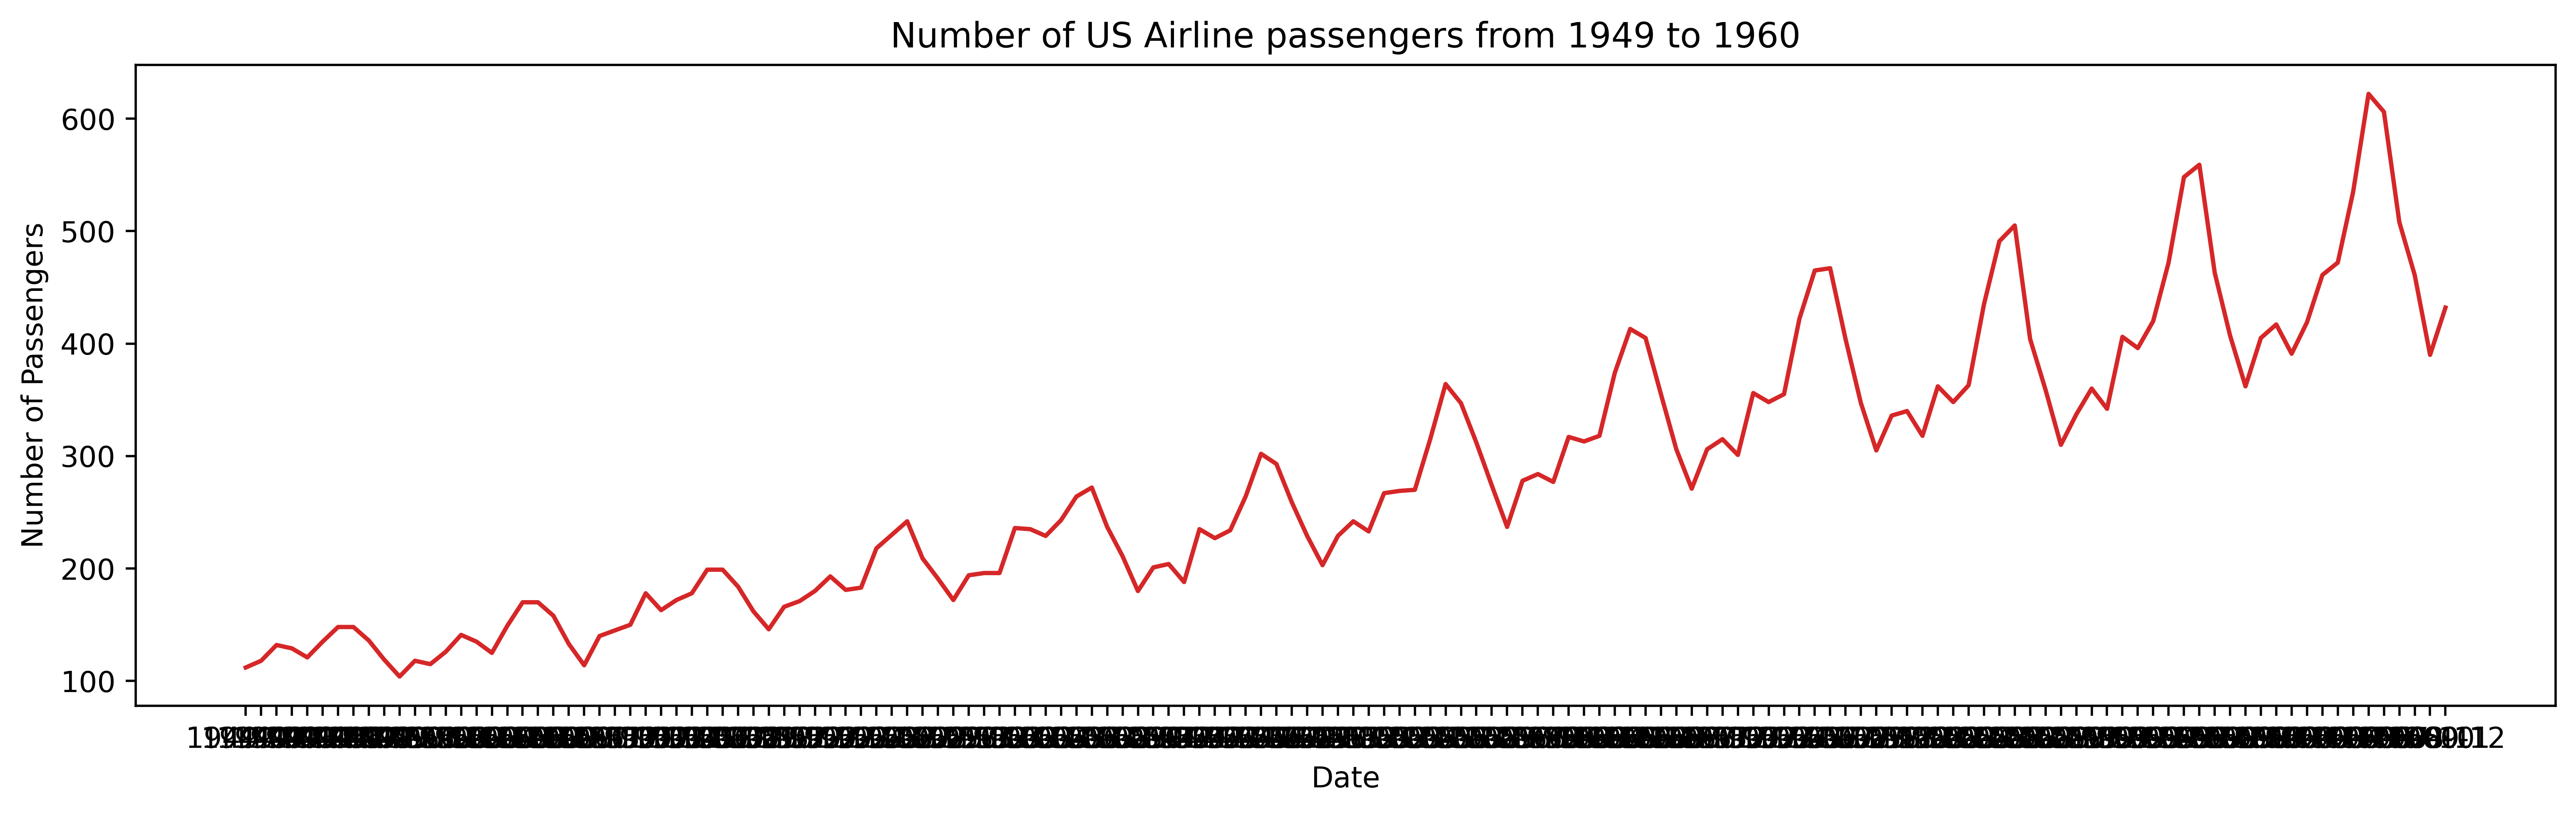

In [5]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Number of Passengers', dpi=500):
 plt.figure(figsize=(15,4), dpi=dpi)
 plt.plot(x, y, color='tab:red')
 plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
 plt.show()

plot_df(df, x=df['Date'], y=df['Number of Passengers'], title='Number of US Airline passengers from 1949 to 1960')

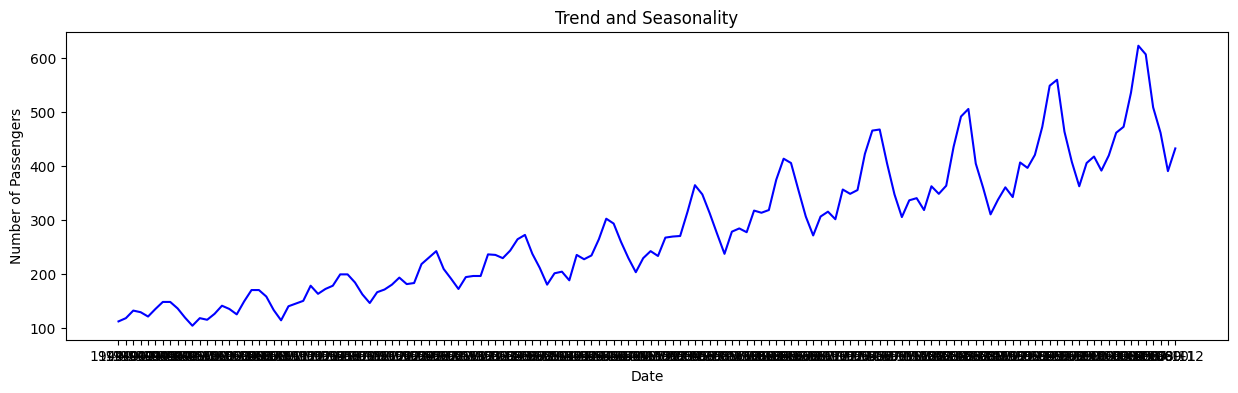

In [24]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Number of Passengers', dpi=100):
 plt.figure(figsize=(15,4), dpi=dpi)
 plt.plot(x, y, color='blue')
 plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
 plt.show()

plot_df(df, x=df['Date'], y=df['Number of Passengers'], title='Trend and Seasonality')


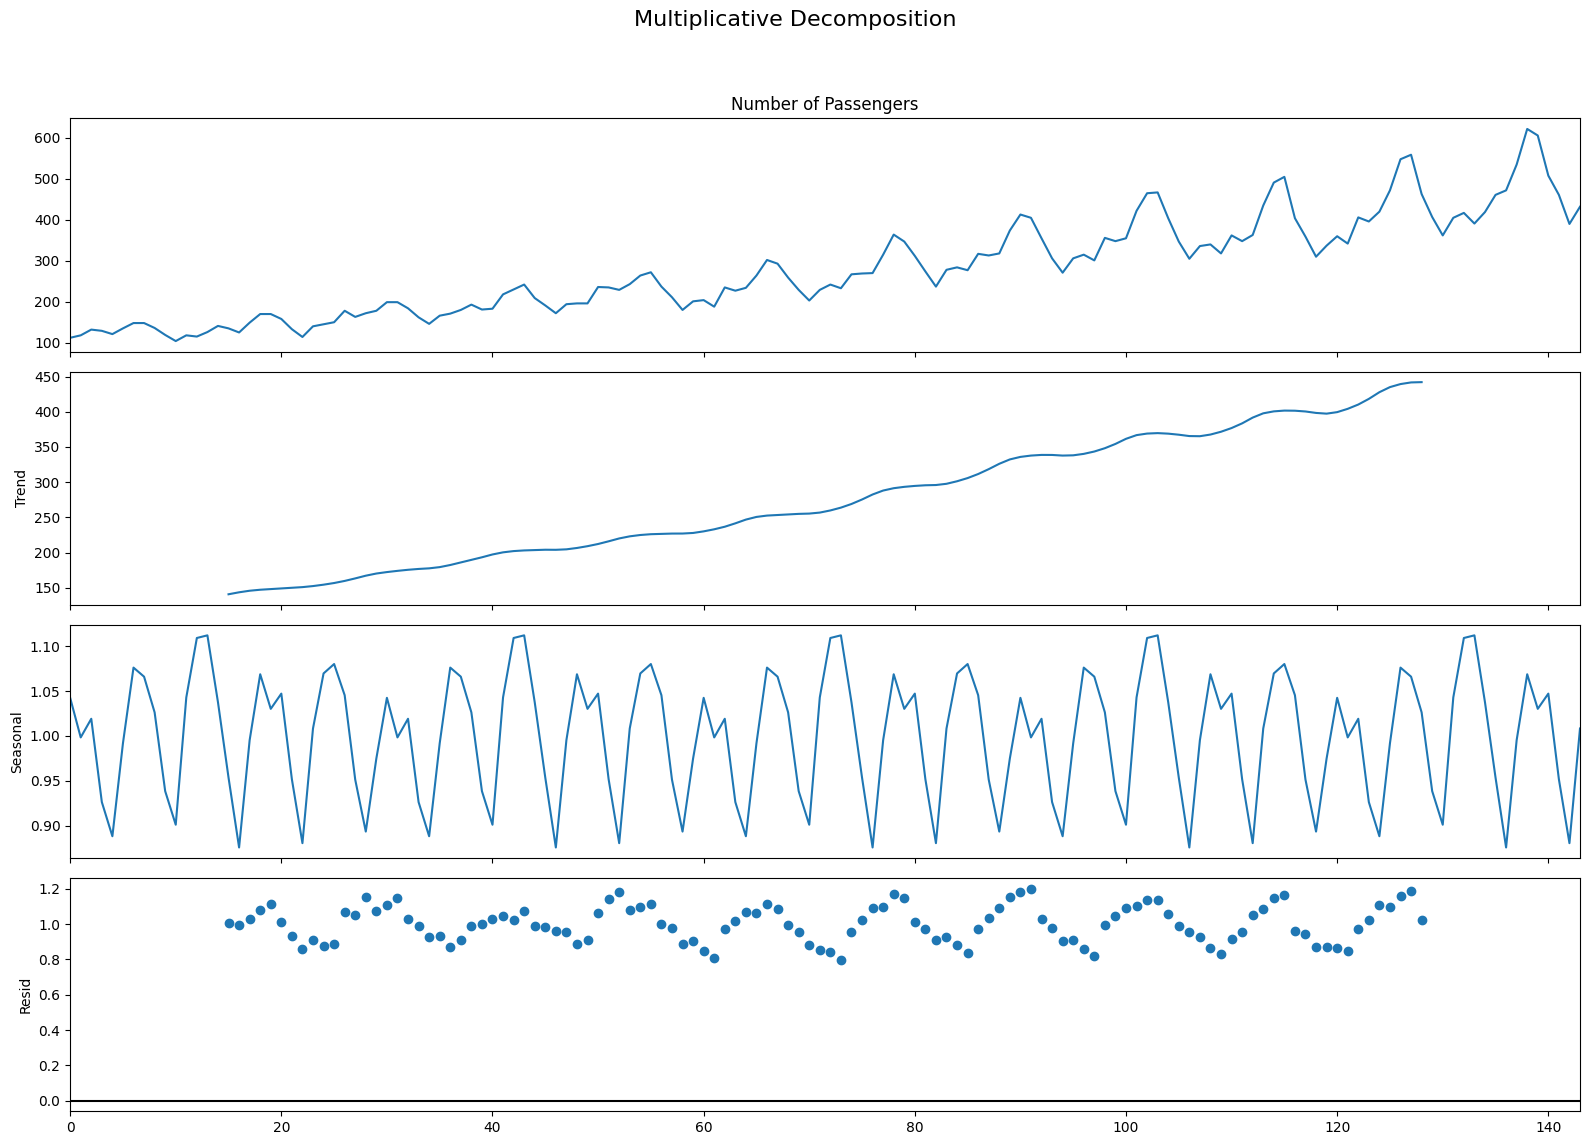

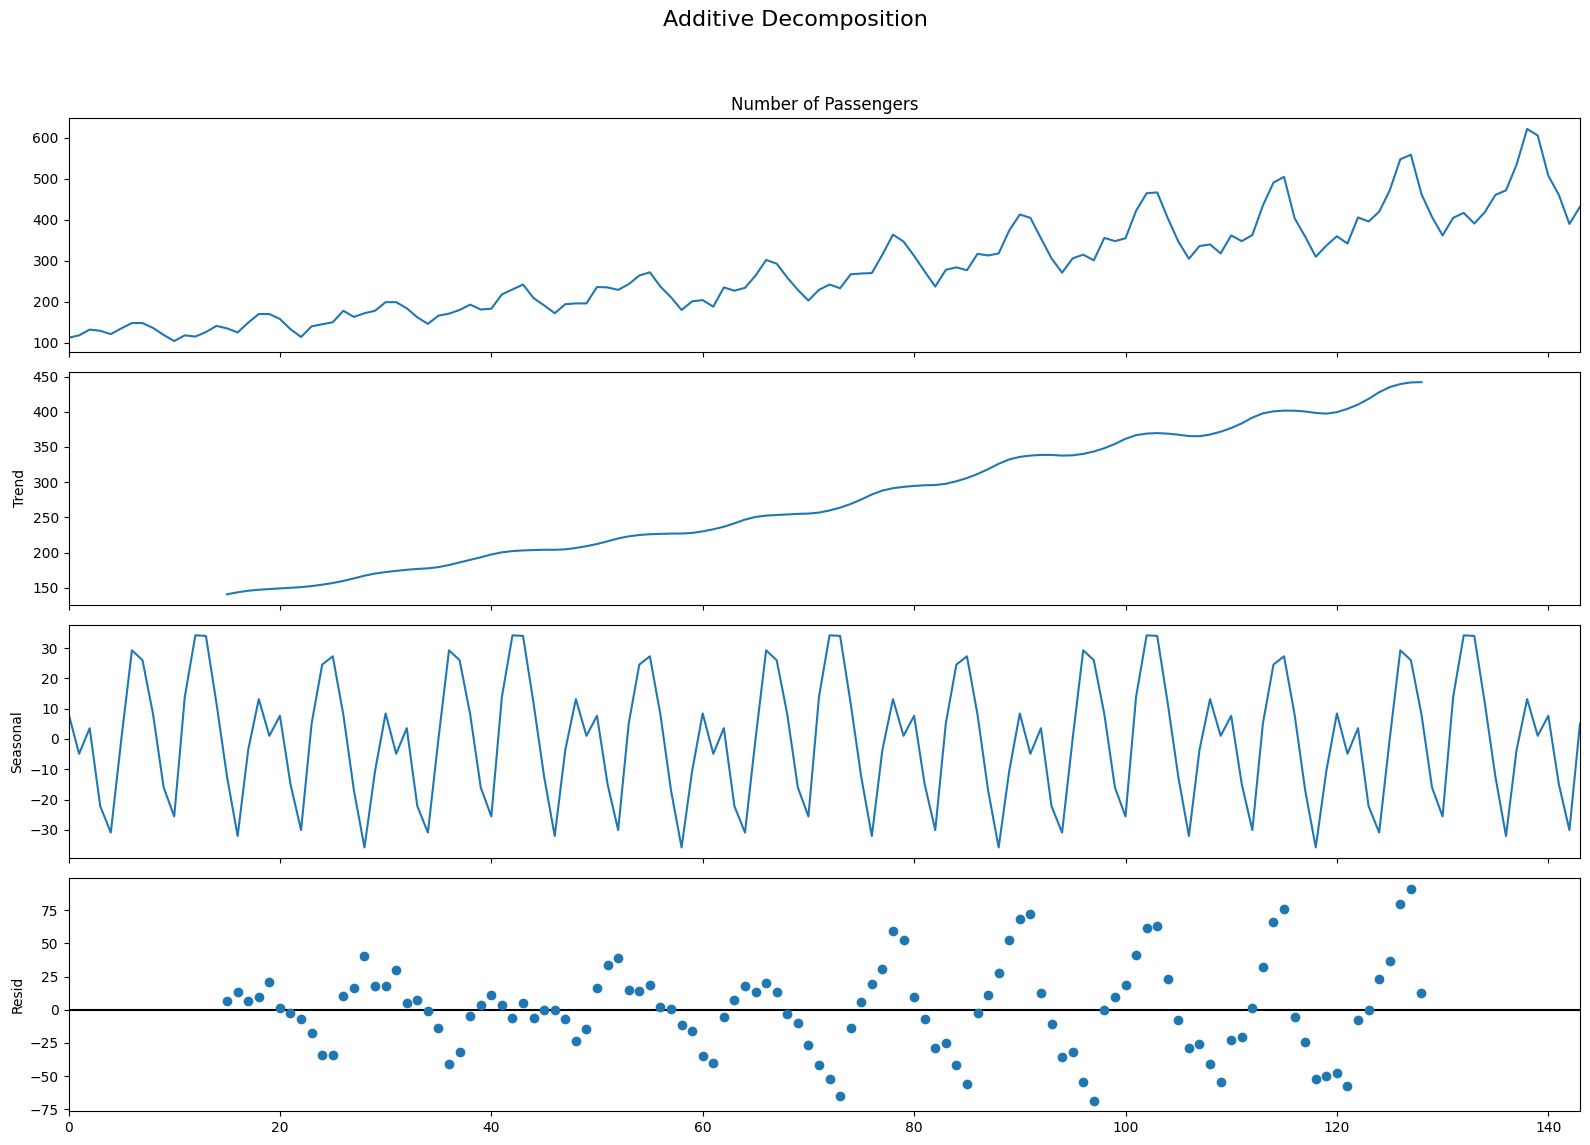

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

# Multiplicative Decomposition
multiplicative_decomposition = seasonal_decompose(df['Number of Passengers'], model='multiplicative', period=30)

# Additive Decomposition
additive_decomposition = seasonal_decompose(df['Number of Passengers'], model='additive', period=30)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

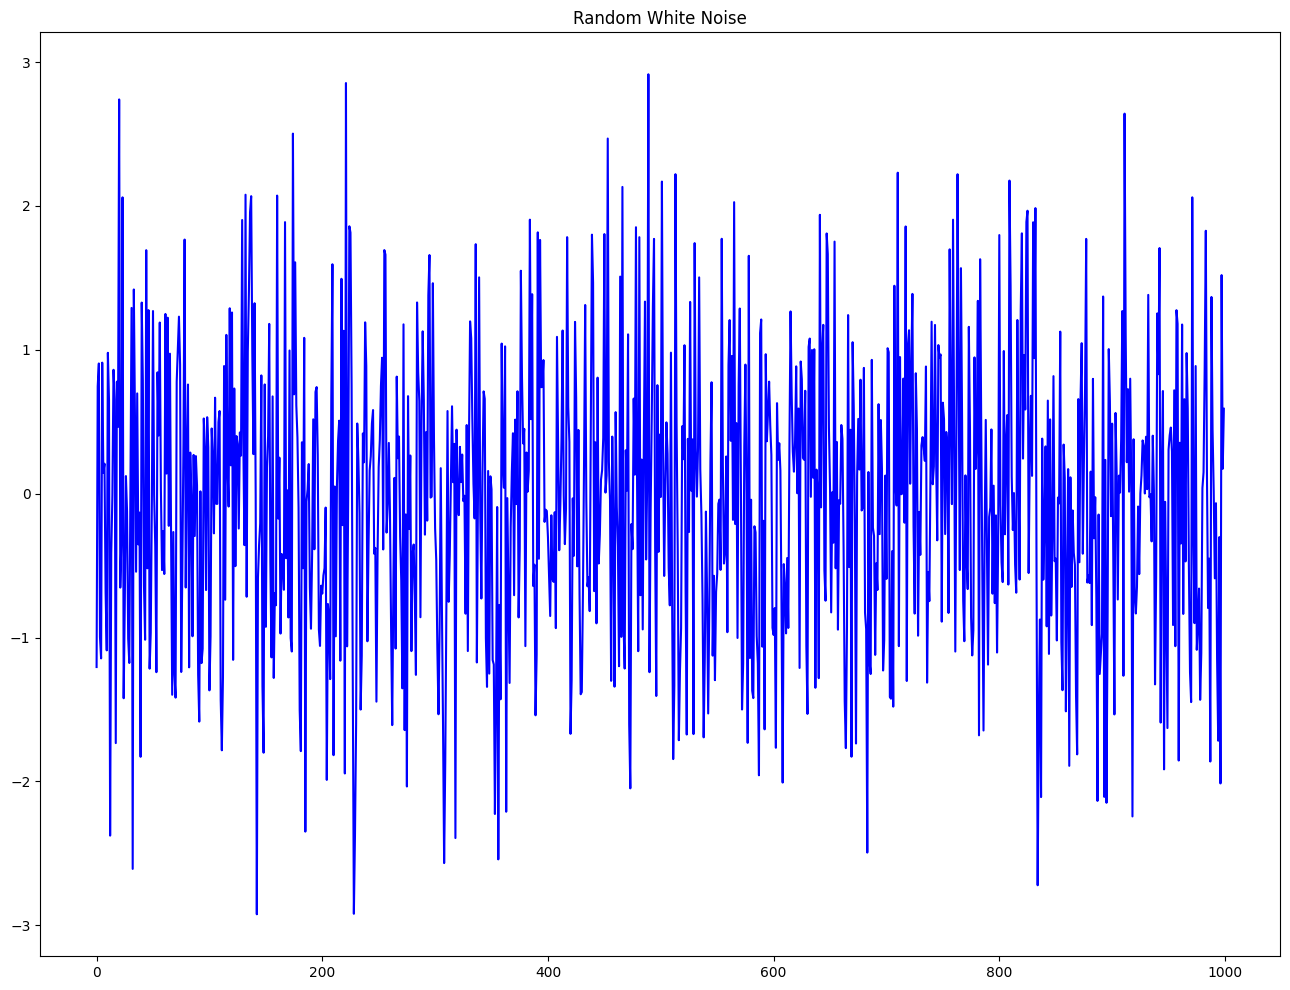

In [39]:
rand_numbers = np.random.randn(1000)
pd.Series(rand_numbers).plot(title='Random White Noise', color='b');

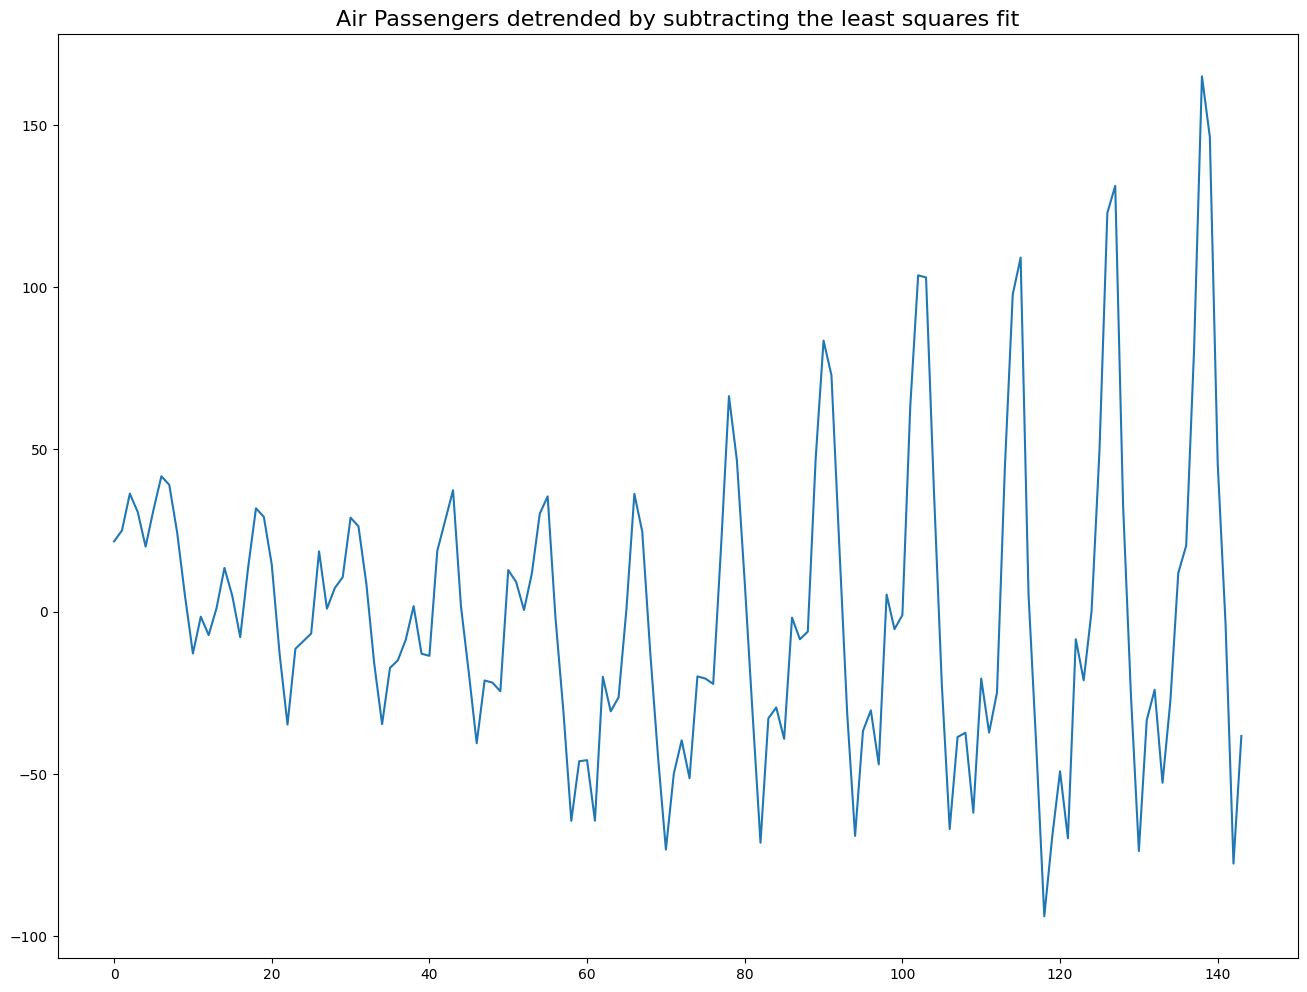

In [38]:
# Using scipy: Subtract the line of best fit
from scipy import signal
detrended = signal.detrend(df['Number of Passengers'].values)
plt.plot(detrended);
plt.title('Air Passengers detrended by subtracting the least squares fit', fontsize=16);

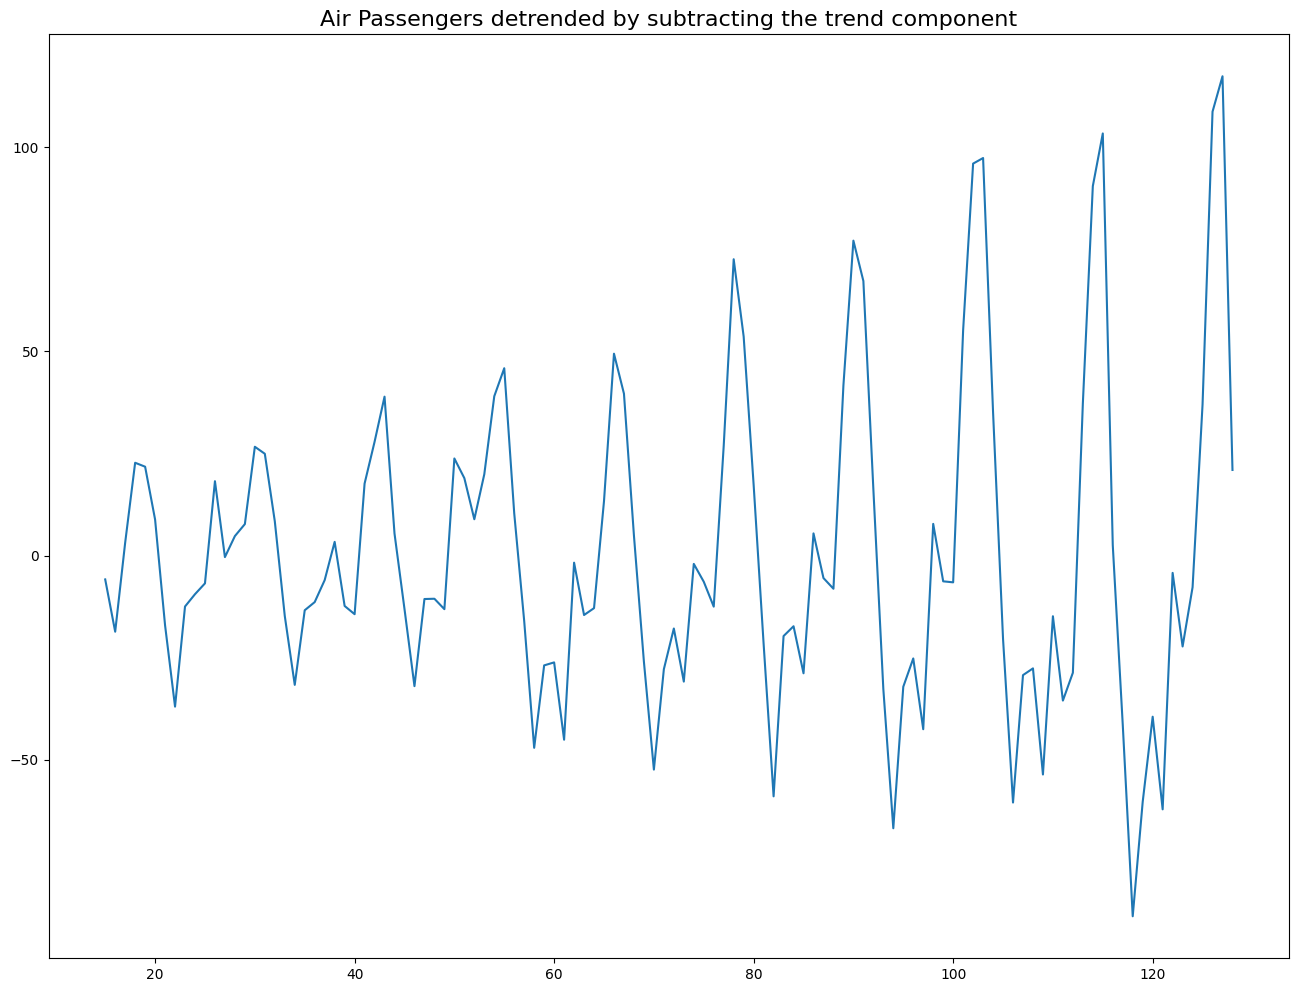

In [37]:
# Using statmodels: Subtracting the Trend Component
from statsmodels.tsa.seasonal import seasonal_decompose
result_mul = seasonal_decompose(df['Number of Passengers'], model='multiplicative', period=30)
detrended = df['Number of Passengers'].values - result_mul.trend
plt.plot(detrended);
plt.title('Air Passengers detrended by subtracting the trend component', fontsize=16);

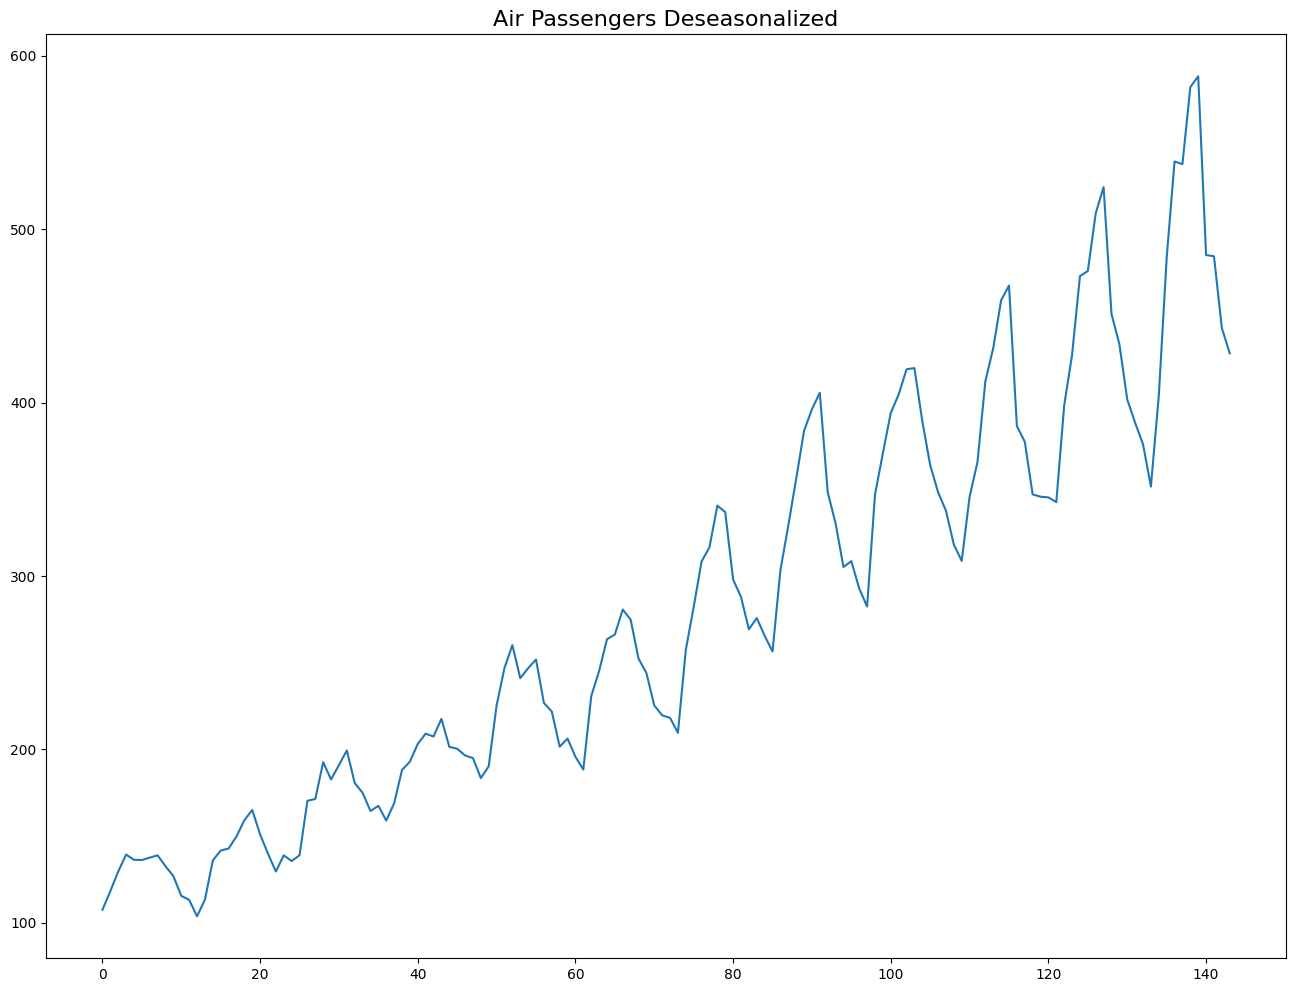

In [41]:
# Subtracting the Trend Component

# Time Series Decomposition
result_mul = seasonal_decompose(df['Number of Passengers'], model='multiplicative', period=30)

# Deseasonalize
deseasonalized = df['Number of Passengers'].values / result_mul.seasonal

# Plot
plt.plot(deseasonalized)
plt.title('Air Passengers Deseasonalized', fontsize=16)
plt.plot();


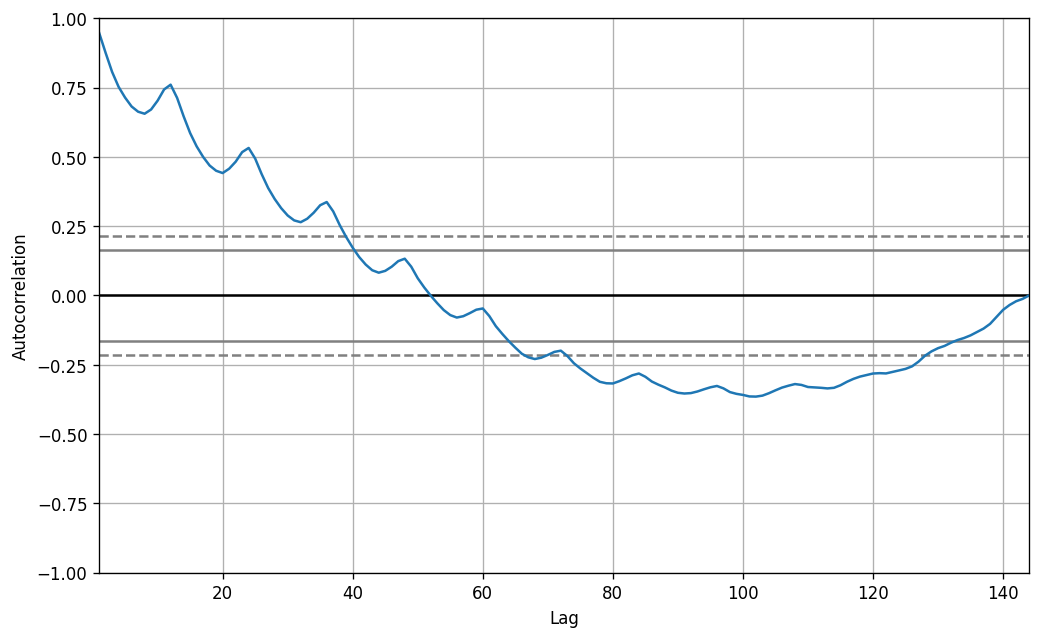

In [43]:
# Test for seasonality
from pandas.plotting import autocorrelation_plot

# Draw Plot
plt.rcParams.update({'figure.figsize':(10,6), 'figure.dpi':120})
autocorrelation_plot(df['Number of Passengers'].tolist());

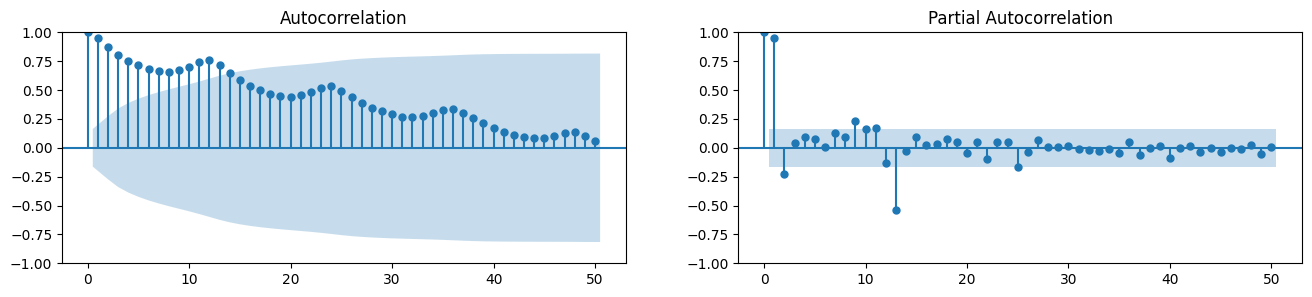

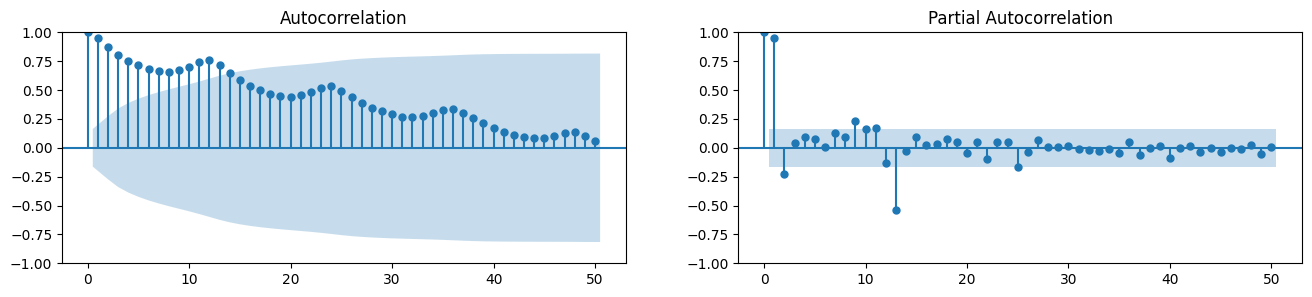

In [44]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Draw Plot
fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(df['Number of Passengers'].tolist(), lags=50, ax=axes[0])
plot_pacf(df['Number of Passengers'].tolist(), lags=50, ax=axes[1])

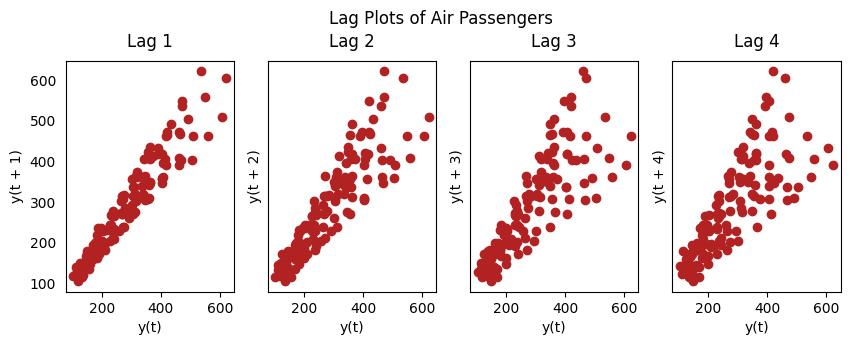

In [45]:
from pandas.plotting import lag_plot
plt.rcParams.update({'ytick.left' : False, 'axes.titlepad':10})

# Plot
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
 lag_plot(df['Number of Passengers'], lag=i+1, ax=ax, c='firebrick')
 ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of Air Passengers', y=1.05)
plt.show()


In [47]:
from statsmodels.tsa.stattools import grangercausalitytests
data = pd.read_csv(r"C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Lab\\Lab 3\\dataset.txt")

data['date'] = pd.to_datetime(data['date'])
data['month'] = data.date.dt.month
grangercausalitytests(data[['value', 'month']], maxlag=2);


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=54.7797 , p=0.0000  , df_denom=200, df_num=1
ssr based chi2 test:   chi2=55.6014 , p=0.0000  , df=1
likelihood ratio test: chi2=49.1426 , p=0.0000  , df=1
parameter F test:         F=54.7797 , p=0.0000  , df_denom=200, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=162.6989, p=0.0000  , df_denom=197, df_num=2
ssr based chi2 test:   chi2=333.6567, p=0.0000  , df=2
likelihood ratio test: chi2=196.9956, p=0.0000  , df=2
parameter F test:         F=162.6989, p=0.0000  , df_denom=197, df_num=2


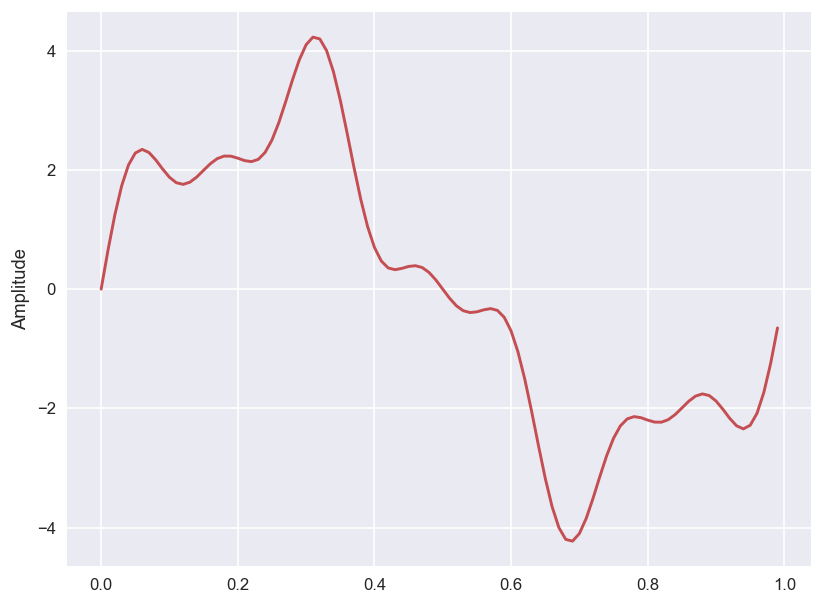

In [52]:
import seaborn as sns
sns.set() # Apply Seaborn style to all Matplotlib plots

import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8')
%matplotlib inline

# sampling rate
sr = 100
# sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

freq = 1.
x = 3*np.sin(2*np.pi*freq*t)

freq = 4
x += np.sin(2*np.pi*freq*t)

freq = 7
x += 0.5* np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 6))
plt.plot(t, x, 'r')
plt.ylabel('Amplitude')
plt.show()


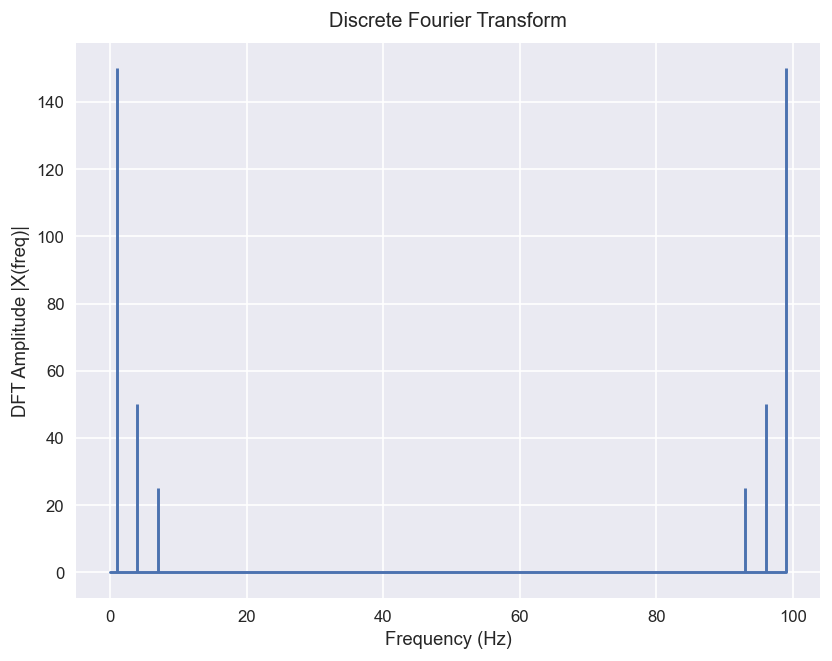

In [70]:
def DFT(x):
 """
 Function to calculate the
 discrete Fourier Transform
 of a 1D real-valued signal x
 """
 N = len(x)
 n = np.arange(N)
 k = n.reshape((N, 1))
 e = np.exp(-2j * np.pi * k * n / N)

 X = np.dot(e, x)
 return X

# Create the signal
sr = 100
ts = 1.0 / sr
t = np.arange(0, 1, ts)

freq = 1.0
x = 3 * np.sin(2 * np.pi * freq * t)
freq = 4
x += np.sin(2 * np.pi * freq * t)
freq = 7
x += 0.5 * np.sin(2 * np.pi * freq * t)

# Apply the DFT function
X = DFT(x)

# Calculate the frequency axis
N = len(X)
n = np.arange(N)
T = N / sr
freq = n / T

# Plot the DFT result
plt.figure(figsize=(8, 6))
plt.stem(freq, np.abs(X), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Frequency (Hz)')
plt.ylabel('DFT Amplitude |X(freq)|')
plt.title('Discrete Fourier Transform')
plt.show()

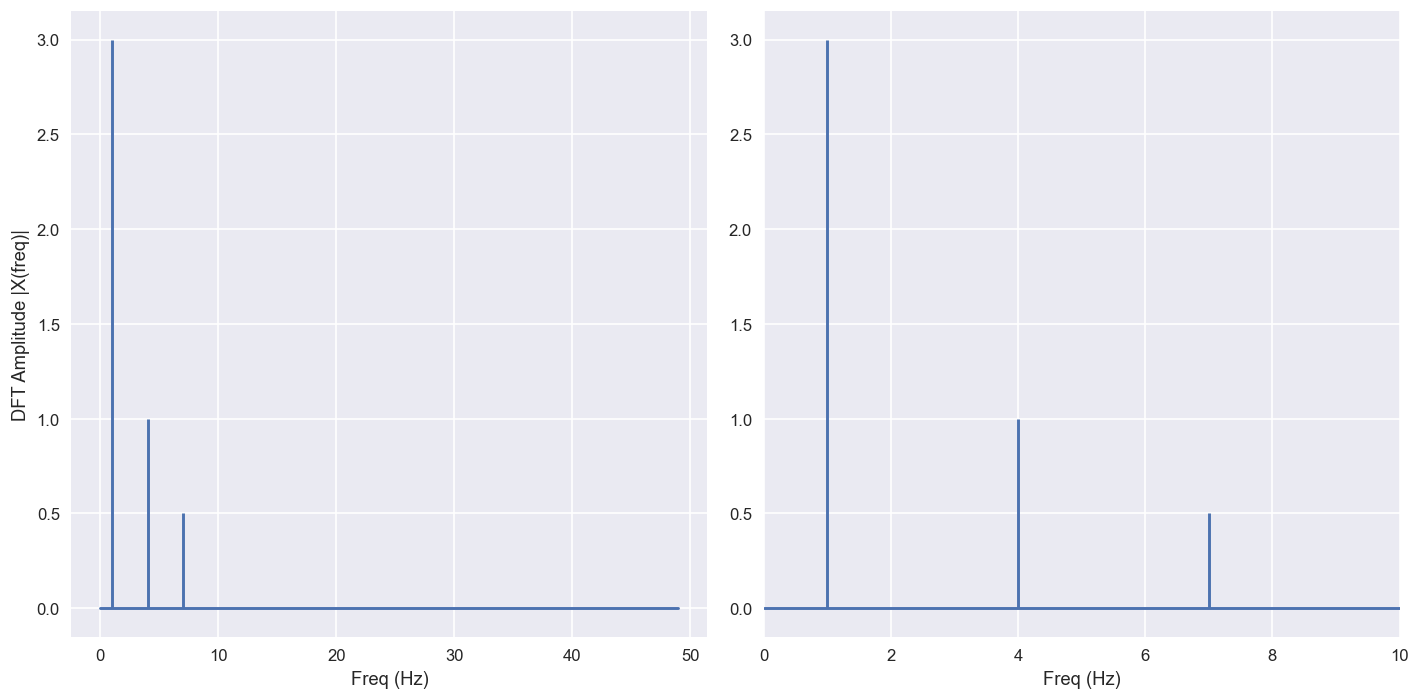

In [68]:
n_oneside = N//2
# get the one side frequency
f_oneside = freq[:n_oneside]

# normalize the amplitude
X_oneside =X[:n_oneside]/n_oneside

plt.figure(figsize = (12, 6))
plt.subplot(121)
plt.stem(f_oneside, abs(X_oneside), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('DFT Amplitude |X(freq)|')

plt.subplot(122)
plt.stem(f_oneside, abs(X_oneside), 'b', markerfmt=" ", basefmt="-b");
plt.xlabel('Freq (Hz)')
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

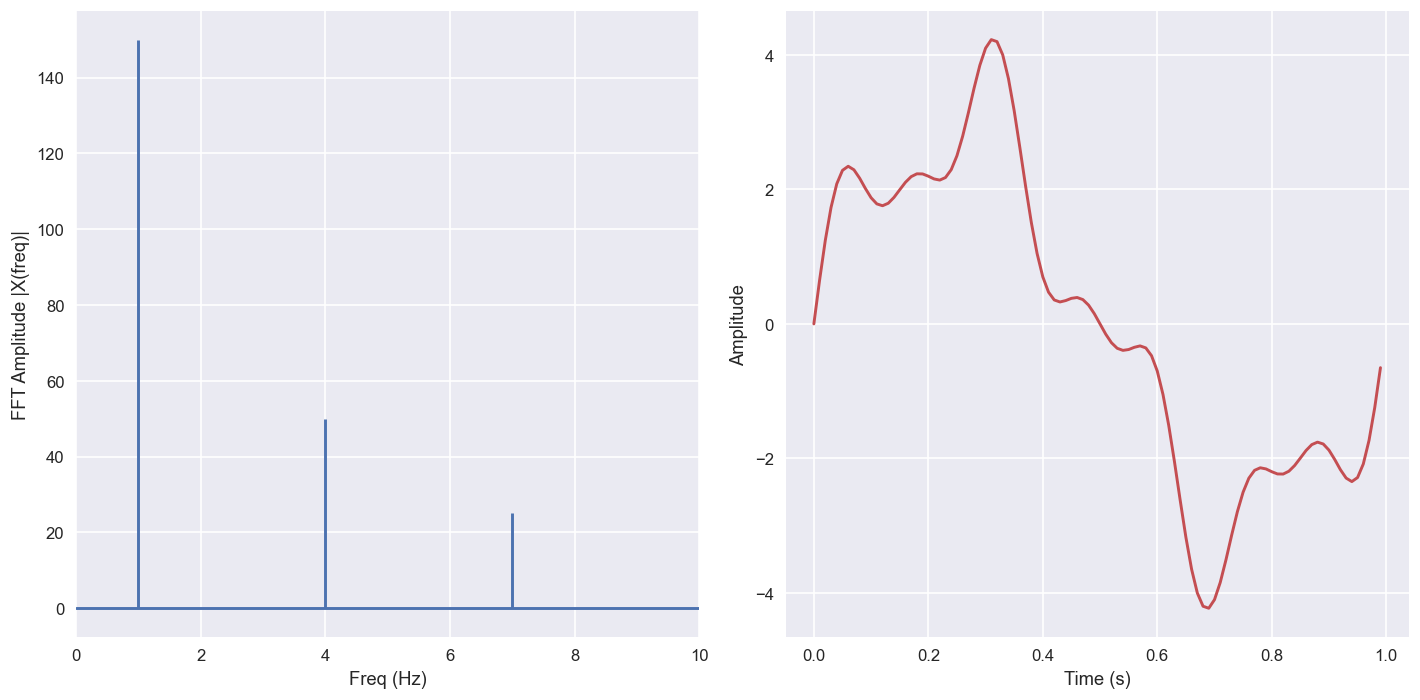

33 μs ± 14.7 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [66]:
from numpy.fft import fft, ifft

X = fft(x)
N = len(X)
n = np.arange(N)
T = N/sr
freq = n/T

plt.figure(figsize = (12, 6))
plt.subplot(121)

plt.stem(freq, np.abs(X), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.xlim(0, 10)

plt.subplot(122)
plt.plot(t, ifft(X), 'r')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()
%timeit fft(x)

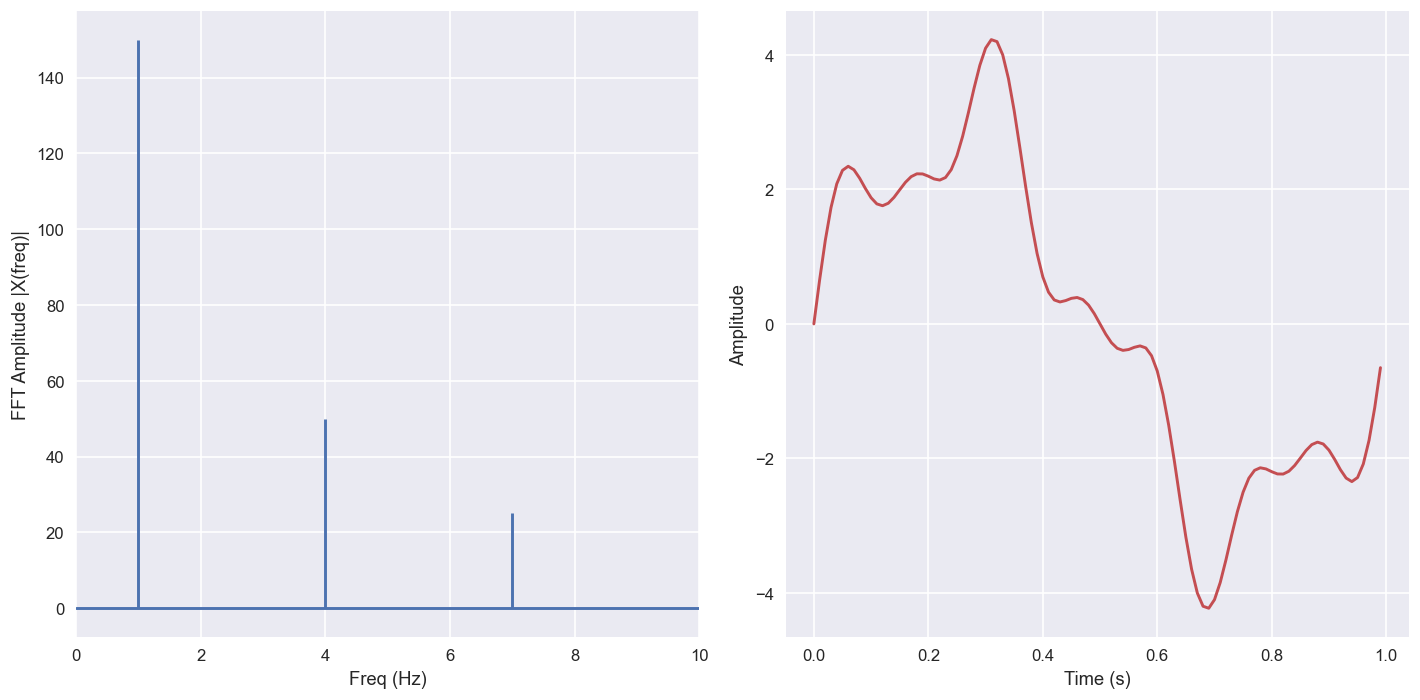

5.64 μs ± 151 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [71]:
from scipy.fftpack import fft, ifft

X = fft(x)

plt.figure(figsize = (12, 6))
plt.subplot(121)

plt.stem(freq, np.abs(X), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.xlim(0, 10)

plt.subplot(122)
plt.plot(t, ifft(X), 'r')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()
%timeit fft(x)

C:\Users\rares\AppData\Local\Temp\ipykernel_32016\3087482501.py:6: FutureWarning: Parsed string "9/28/2024 12 a.m. PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df = pd.read_csv('C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Lab\\Lab 3\\930-data-export.csv', delimiter=',', parse_dates=[1])
C:\Users\rares\AppData\Local\Temp\ipykernel_32016\3087482501.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Lab\\Lab 3\\930-data-export.csv', delimiter=',', parse_dates=[1])
C:\Users\rares\AppData\Local\Temp\ipykernel_32016\3087482501.py:6: FutureWarning: Parsed string "9/28/2024 1 a.m. PDT" inc

Index(['Region Code', 'Timestamp (Hour Ending)', 'BANC Demand (MWh)',
       'CISO Demand (MWh)', 'IID Demand (MWh)', 'LDWP Demand (MWh)',
       'TIDC Demand (MWh)'],
      dtype='object')


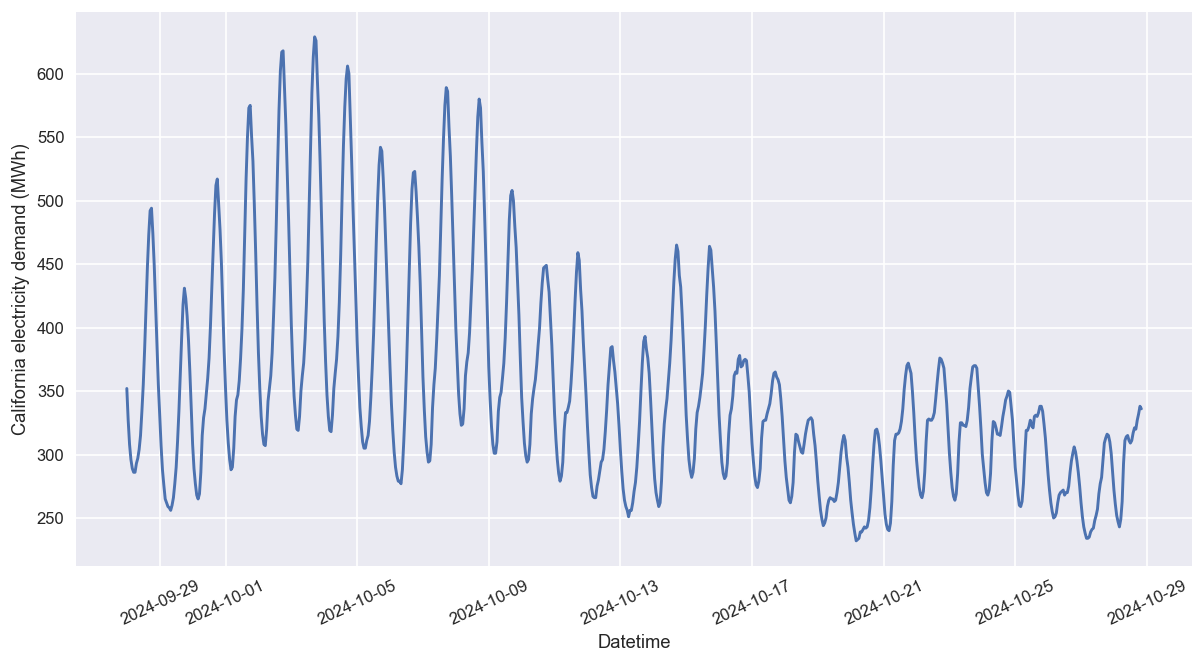

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import fft

df = pd.read_csv('C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Lab\\Lab 3\\930-data-export.csv', delimiter=',', parse_dates=[1])

# Print the column names to confirm their exact spelling
print(df.columns)
df.rename(columns={'Timestamp (Hour Ending)':'hour', 'TIDC Demand (MWh)':'demand'}, inplace=True)

plt.figure(figsize = (12, 6))
plt.plot(df['hour'], df['demand'])
plt.xlabel('Datetime')
plt.ylabel('California electricity demand (MWh)')
plt.xticks(rotation=25)
plt.show()

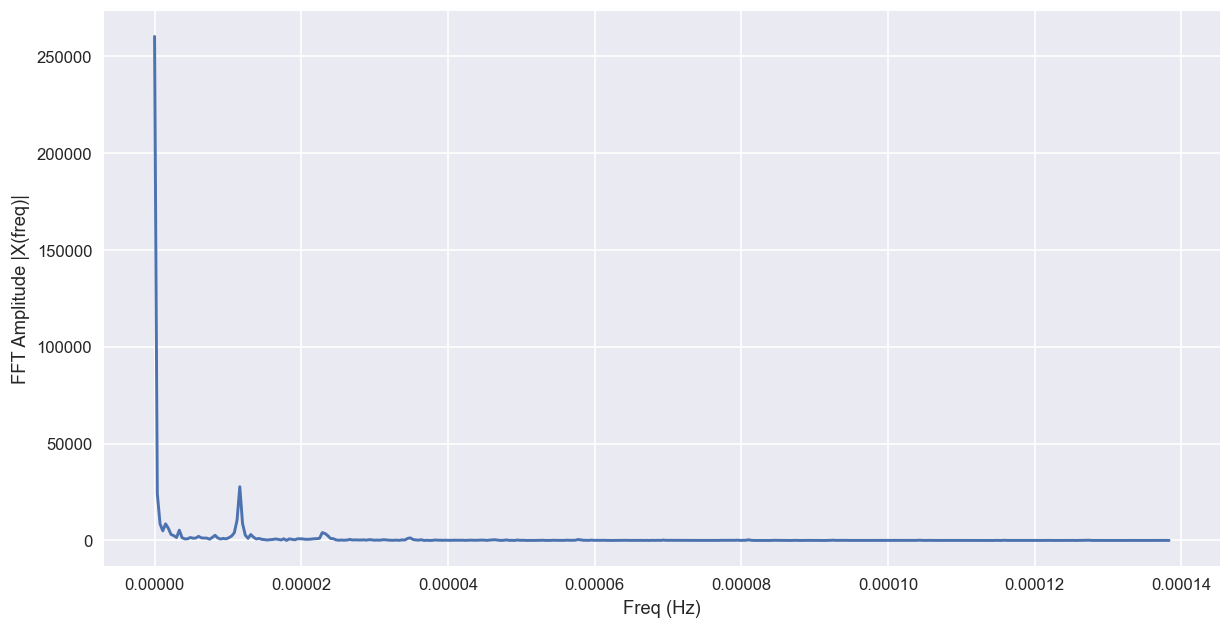

In [79]:
X = fft(df['demand'])
N = len(X)
n = np.arange(N)
# get the sampling rate
sr = 1 / (60*60)
T = N/sr
freq = n/T

# Get the one-sided specturm
n_oneside = N//2
# get the one side frequency
f_oneside = freq[:n_oneside]

plt.figure(figsize = (12, 6))
plt.plot(f_oneside, np.abs(X[:n_oneside]), 'b')
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.show()

C:\Users\rares\AppData\Local\Temp\ipykernel_32016\1034189290.py:2: RuntimeWarning: divide by zero encountered in divide
  t_h = 1/f_oneside / (60 * 60)


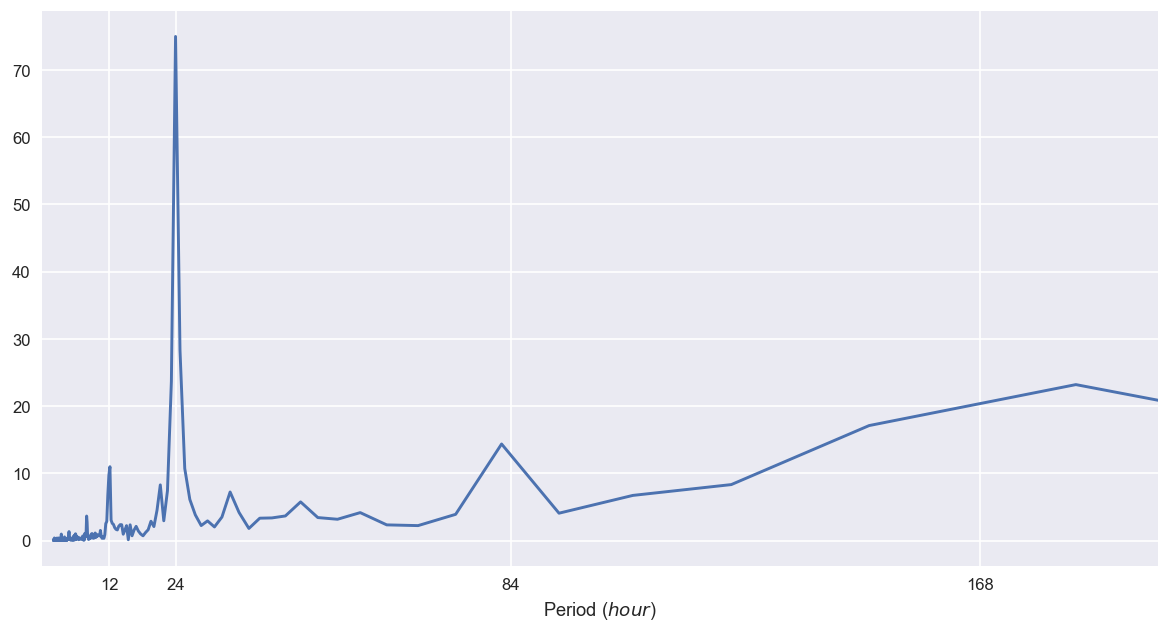

In [80]:
# convert frequency to hour
t_h = 1/f_oneside / (60 * 60)

plt.figure(figsize=(12,6))
plt.plot(t_h, np.abs(X[:n_oneside])/n_oneside)
plt.xticks([12, 24, 84, 168])
plt.xlim(0, 200)
plt.xlabel('Period ($hour$)')
plt.show()

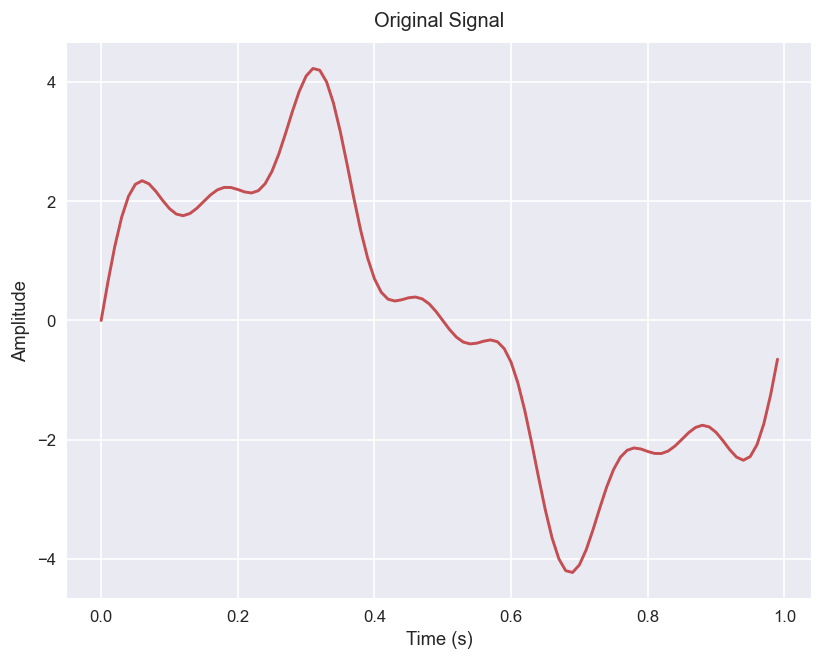

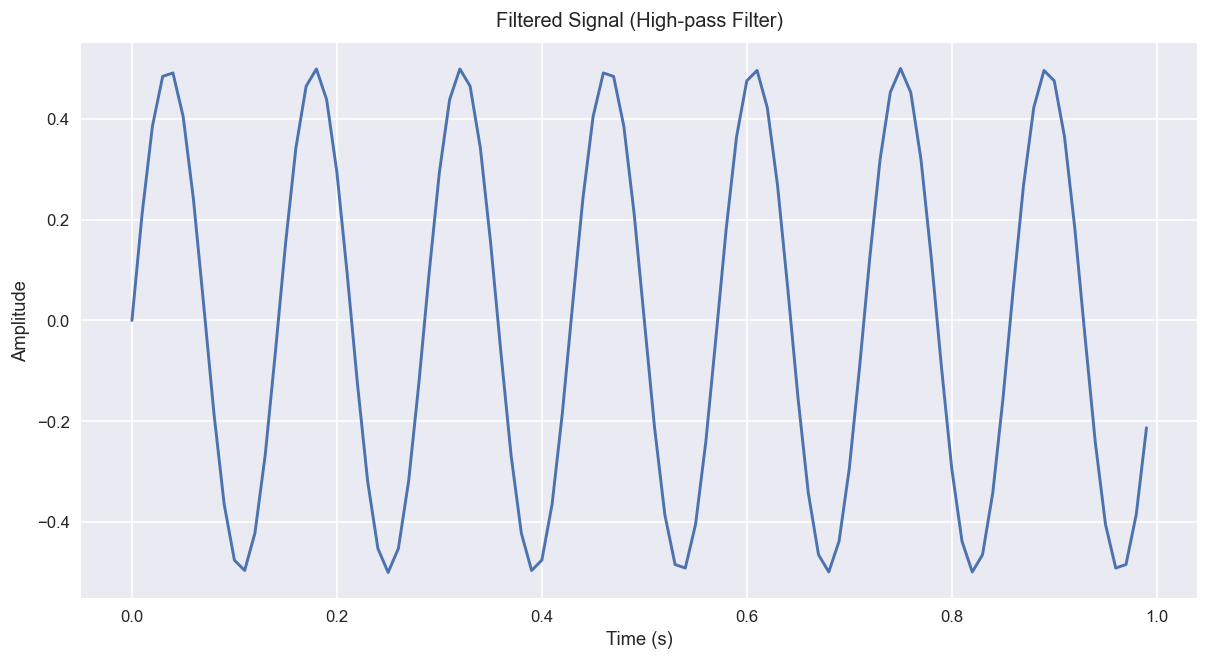

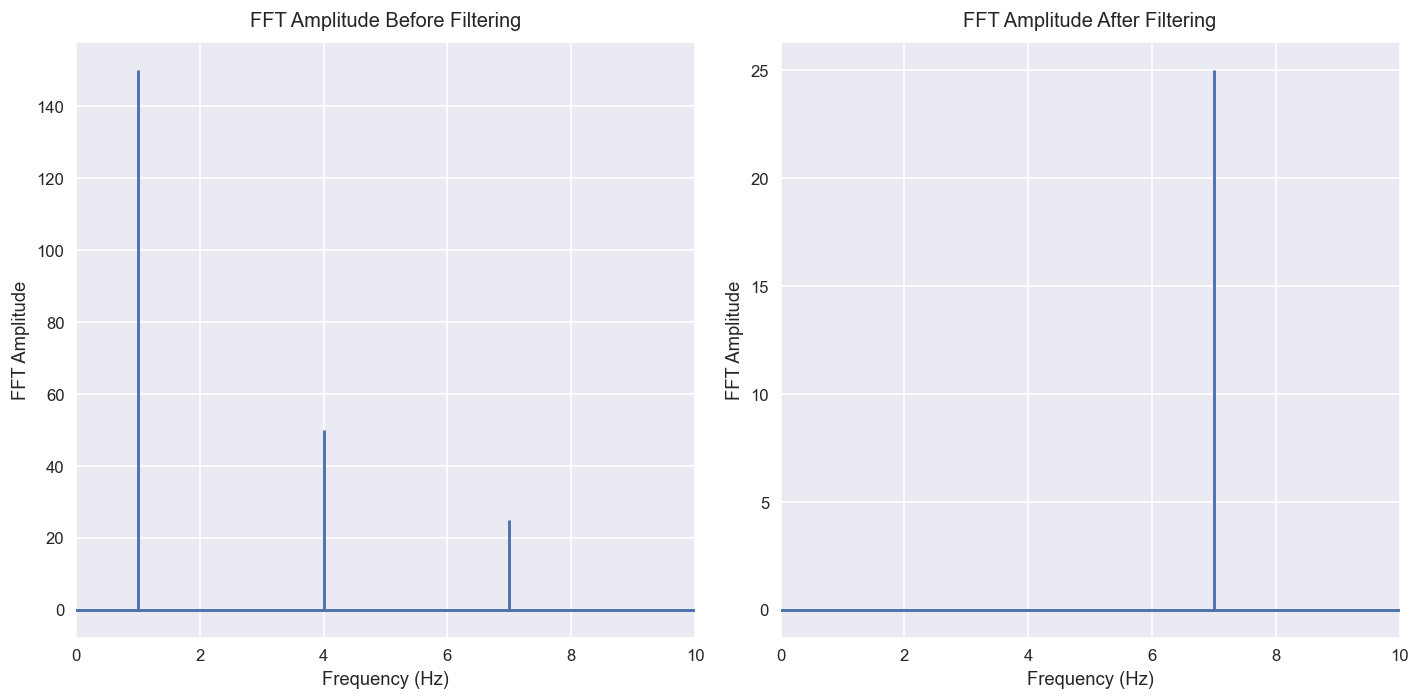

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# Sampling rate and time vector
sr = 100 # Sampling rate in Hz
ts = 1.0 / sr # Sampling interval
t = np.arange(0, 1, ts) # Time vector

# Generate the signal with multiple frequencies
x = 3 * np.sin(2 * np.pi * 1 * t) # Frequency of 1 Hz
x += np.sin(2 * np.pi * 4 * t) # Frequency of 4 Hz
x += 0.5 * np.sin(2 * np.pi * 7 * t) # Frequency of 7 Hz

# Plot the original signal
plt.figure(figsize=(8, 6))
plt.plot(t, x, 'r')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Original Signal')
plt.show()

from scipy.fft import fft, ifft
from scipy.fftpack import fftfreq

# FFT of the signal
sig_fft = fft(x)

# Make a copy of FFT results for filtering
sig_fft_filtered = sig_fft.copy()

# Obtain frequencies and define the cutoff frequency
freq = fftfreq(len(x), d=1./sr)
cut_off = 6 # Cut-off frequency in Hz

# Apply high-pass filter by zeroing out low frequencies
sig_fft_filtered[np.abs(freq) < cut_off] = 0

# Inverse FFT to get the filtered signal in the time domain
filtered = ifft(sig_fft_filtered).real

# Plot the filtered signal
plt.figure(figsize=(12, 6))
plt.plot(t, filtered)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Filtered Signal (High-pass Filter)')
plt.show()

# Plot FFT amplitude before and after filtering
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.stem(freq, np.abs(sig_fft), 'b', markerfmt=" ", basefmt="-b")
plt.title('FFT Amplitude Before Filtering')
plt.xlim(0, 10)
plt.xlabel('Frequency (Hz)')
plt.ylabel('FFT Amplitude')
plt.subplot(122)
plt.stem(freq, np.abs(sig_fft_filtered), 'b', markerfmt=" ", basefmt="-b")
plt.title('FFT Amplitude After Filtering')
plt.xlim(0, 10)
plt.xlabel('Frequency (Hz)')
plt.ylabel('FFT Amplitude')
plt.tight_layout()
plt.show()